# Correlation Analysis & Advanced Insights

## Objective

The purpose of this analysis is to identify relationships between variables and uncover deeper business insights that are not immediately visible through descriptive analysis.

Key Questions:

- Does selling more units lead to higher revenue?
- Are there relationships between order quantity and sales amount?
- Which categories have the highest revenue per unit sold?
- What hidden patterns exist in the dataset?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/cleaned_amazon_sales.csv')

df['Date'] = pd.to_datetime(df['Date'])

In [4]:
df[['Qty', 'Amount']].describe()

,Qty,Amount
count,128775.000000,120988.000000
mean,0.904430,648.643794
std,0.313359,281.235025
min,0.000000,0.000000
25%,1.000000,449.000000
50%,1.000000,605.000000
75%,1.000000,788.000000
max,15.000000,5584.000000


In [5]:
corr_matrix = df[['Qty', 'Amount']].corr()

corr_matrix

,Qty,Amount
Qty,1.000000,0.066713
Amount,0.066713,1.000000


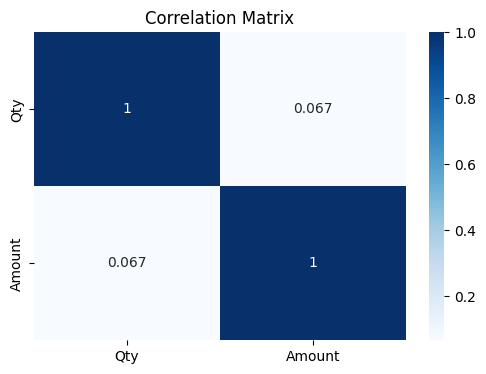

In [6]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Matrix')

plt.show()

## Correlation Insight

The correlation coefficient indicates the strength and direction of the relationship between Quantity Sold and Revenue.

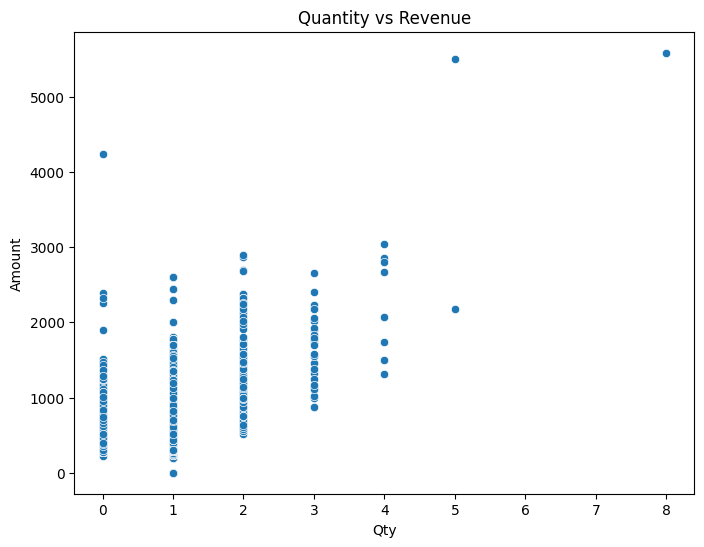

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Qty',
    y='Amount'
)

plt.title('Quantity vs Revenue')

plt.show()

In [8]:
category_summary = (
    df.groupby('Category')
    .agg({
        'Qty':'sum',
        'Amount':'sum'
    })
)

category_summary['Revenue_Per_Unit'] = (
    category_summary['Amount'] /
    category_summary['Qty']
)

category_summary.sort_values(
    'Revenue_Per_Unit',
    ascending=False
).head(10)

,Qty,Amount,Revenue_Per_Unit
Category,,,
T-shirt,45217,39145184.17,865.718296
Shoes,152,123933.76,815.353684
Blazzer,13933,11207771.12,804.404731
Perfume,1051,789419.66,751.112902
Trousers,9887,5340325.30,540.136068
Wallet,863,458408.18,531.179815
Shirt,44964,21261760.70,472.861861
Socks,398,150397.50,377.883166
Watch,3,915.00,305.000000


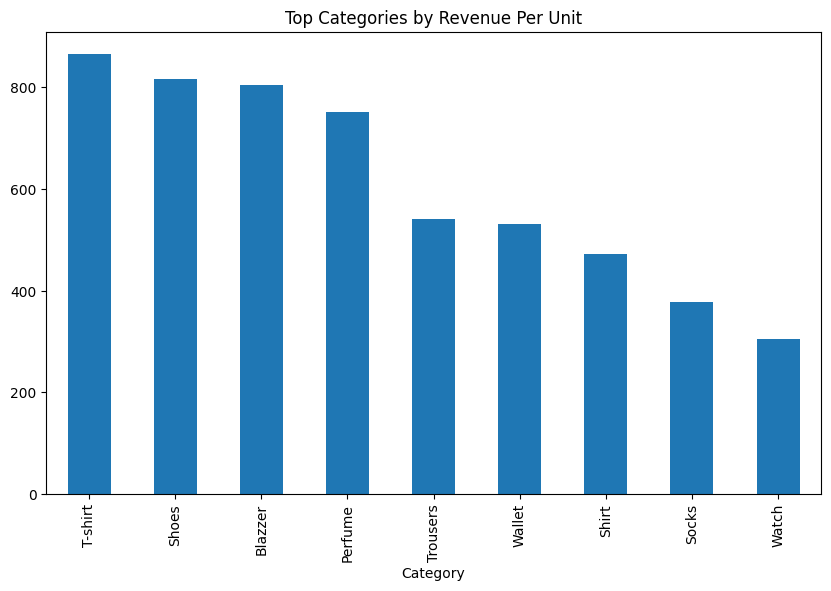

In [9]:
category_summary[
    'Revenue_Per_Unit'
].sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Top Categories by Revenue Per Unit'
)

plt.show()

## Revenue Efficiency Insight

Some categories generate significantly more revenue per unit sold, indicating premium pricing or higher product value.

In [10]:
category_summary.head()

,Qty,Amount,Revenue_Per_Unit
Category,,,
Blazzer,13933,11207771.12,804.404731
Perfume,1051,789419.66,751.112902
Shirt,44964,21261760.70,472.861861
Shoes,152,123933.76,815.353684
Socks,398,150397.50,377.883166


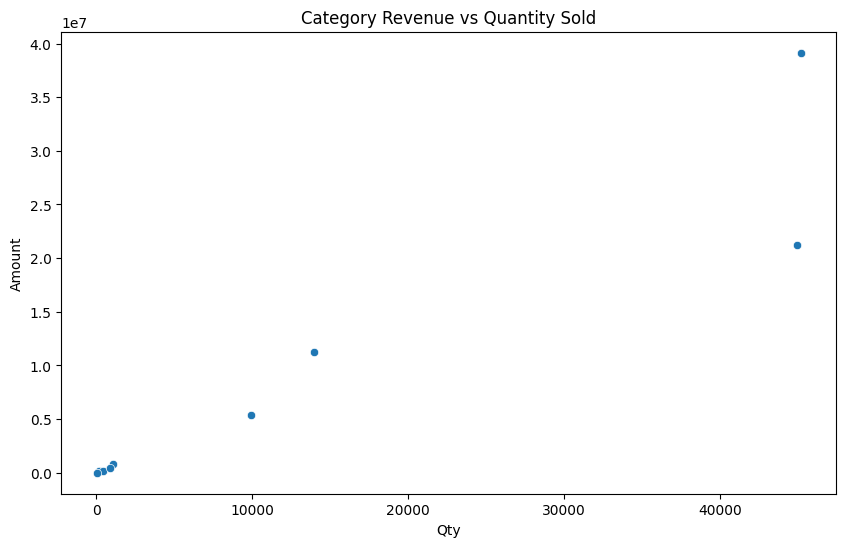

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=category_summary,
    x='Qty',
    y='Amount'
)

plt.title(
    'Category Revenue vs Quantity Sold'
)

plt.show()

In [12]:
cancelled_orders = df[
    df['Status'].str.contains(
        'Cancelled',
        case=False,
        na=False
    )
]

cancelled_orders.shape

(18304, 19)

In [13]:
cancelled_orders['Qty'].sum()

np.int64(5649)

## Cancellation Impact

Cancelled orders represent lost revenue opportunities and may indicate operational inefficiencies or customer dissatisfaction.

In [14]:
insights = pd.DataFrame({
    'Insight Area':[
        'Revenue',
        'Orders',
        'Category',
        'Geography',
        'Fulfillment'
    ],
    'Key Observation':[
        'Revenue peaked in April 2022 and declined gradually in subsequent months.',
        'Approximately 14.2% of orders were cancelled, indicating opportunities for operational improvement.',
        'The T-shirt category emerged as the primary revenue driver, suggesting that inventory and marketing investments should be prioritized for this product segment',
        'Maharashtra generated the highest revenue among all states.',
        'Amazon fulfilled most orders, while Merchant fulfillment showed a higher cancellation rate.'
    ]
})

insights

,Insight Area,Key Observation
0,Revenue,Revenue peaked in April 2022 and declined grad...
1,Orders,"Approximately 14.2% of orders were cancelled, ..."
2,Category,The T-shirt category emerged as the primary re...
3,Geography,Maharashtra generated the highest revenue amon...
4,Fulfillment,"Amazon fulfilled most orders, while Merchant f..."


# Advanced Business Insights

## Key Findings

1. Correlation between Quantity and Revenue:
2. Highest Revenue Per Unit Category:
3. Most Revenue Efficient Category:
4. Cancellation Impact:
5. Key Business Opportunity:

## Conclusion

The analysis reveals important relationships between sales volume, revenue generation, and category performance. These insights can support inventory planning, pricing strategies, and operational improvements.